# Molecular Shape Conditioning: Coordinate Eigenvalues Demonstration

This notebook demonstrates how to compute and visualize **associated shape-conditioning eigenvalues** for molecules. 

It is designed to be **fully self-contained**—it will generate and process synthetic molecules (linear, planar, and 3D) on the fly, and will optionally load the preprocessed QM9/GEOM-Drugs datasets if they are available.

## Background: What are Coordinate Eigenvalues?
For a molecule with $N$ atom positions represented by the coordinates matrix $X \in \mathbb{R}^{N 	imes 3}$:
1. **Center of Mass / Mean Centering**: We translate the coordinates to the center of mass:
   $$X_c = X - \frac{1}{N} \sum_{i=1}^N X_i$$
   where $X_c \in \mathbb{R}^{N 	imes 3}$.
2. **Covariance Matrix**: We compute the $3 	imes 3$ coordinate covariance matrix:
   $$C = \frac{1}{N} X_c^T X_c$$
   Alternatively, we can compute the unnormalized Gram matrix $G = X_c^T X_c$, which is $N$ times the covariance.
3. **Eigendecomposition**: Since $C$ is a symmetric positive semi-definite matrix, we perform eigendecomposition to find its 3 real eigenvalues:
   $$\lambda_1 \ge \lambda_2 \ge \lambda_3 \ge 0$$
   and their corresponding eigenvectors $v_1, v_2, v_3$.

## Why is this useful for Shape Conditioning?
* **Rotational and Translational Invariance**: Eigendecomposition is invariant to translation (since we mean-center) and rotation (rotating coordinates rotates the eigenvectors but keeps the eigenvalues identical).
* **Geometric Meaning**: The eigenvalues represent the variance of the atom coordinates along the three principal axes (the eigenvectors).
  * **Linear Molecules**: $\lambda_1 > 0$, while $\lambda_2 \approx \lambda_3 \approx 0$.
  * **Planar Molecules**: $\lambda_1 \ge \lambda_2 > 0$, while $\lambda_3 \approx 0$.
  * **3D Spherical/Globular Molecules**: $\lambda_1 \approx \lambda_2 \approx \lambda_3 > 0$.


In [25]:
import os
import torch
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt

# Periodic table mapping for QM9 / GEOM-Drugs / Synthetic
ATOM_MAP = {
    1: {'symbol': 'H', 'color': 'white', 'size': 8},
    6: {'symbol': 'C', 'color': 'gray', 'size': 12},
    7: {'symbol': 'N', 'color': 'blue', 'size': 12},
    8: {'symbol': 'O', 'color': 'red', 'size': 12},
    9: {'symbol': 'F', 'color': 'green', 'size': 12},
    15: {'symbol': 'P', 'color': 'orange', 'size': 14},
    16: {'symbol': 'S', 'color': 'yellow', 'size': 14},
    17: {'symbol': 'Cl', 'color': 'darkgreen', 'size': 14},
    35: {'symbol': 'Br', 'color': 'brown', 'size': 15},
    53: {'symbol': 'I', 'color': 'purple', 'size': 16}
}

def compute_eigenvalues_and_scale_axes(pos: torch.Tensor):
    com = pos.mean(dim=0, keepdim=True)
    pos_centered = pos - com
    cov = torch.matmul(pos_centered.T, pos_centered)
    
    e_unnorm, v = torch.linalg.eigh(cov)
    # Sort eigenvalues
    idx = torch.argsort(e_unnorm, descending=True)
    e_unnorm = e_unnorm[idx]
    v = v[:, idx]
    
    e_unnorm = torch.clamp(e_unnorm, min=0.0)
    E = torch.sqrt(e_unnorm)
    S = E.sum()
    S_safe = max(S.item(), 1e-8)
    s_hat = E / S_safe
    
    c = torch.cat([s_hat, torch.tensor([S])])
    
    return {
        'com': com.squeeze(0),
        'c': c,
        'E': E,
        'eigenvectors': v
    }

def visualize_molecule_shape_axes(pos: torch.Tensor, atomic_numbers: torch.Tensor, title_prefix=""):
    results = compute_eigenvalues_and_scale_axes(pos)
    com = results['com'].numpy()
    c = results['c'].numpy()
    E = results['E'].numpy()
    v = results['eigenvectors'].numpy()
    
    pos_np = pos.numpy()
    atomic_nums_np = atomic_numbers.numpy()
    
    symbols = [ATOM_MAP.get(num, {'symbol': 'X', 'color': 'magenta', 'size': 12})['symbol'] for num in atomic_nums_np]
    colors = [ATOM_MAP.get(num, {'symbol': 'X', 'color': 'magenta', 'size': 12})['color'] for num in atomic_nums_np]
    sizes = [ATOM_MAP.get(num, {'symbol': 'X', 'color': 'magenta', 'size': 12})['size'] for num in atomic_nums_np]
    
    atom_trace = go.Scatter3d(
        x=pos_np[:, 0], y=pos_np[:, 1], z=pos_np[:, 2],
        mode='markers+text', text=symbols, textposition='top center',
        marker=dict(size=sizes, color=colors, line=dict(width=1.5, color='black')),
        name='Atoms'
    )
    
    bond_traces = []
    n = len(pos_np)
    for i in range(n):
        for j in range(i + 1, n):
            dist = np.linalg.norm(pos_np[i] - pos_np[j])
            threshold = 1.6 if (symbols[i] != 'H' and symbols[j] != 'H') else 1.2
            if dist <= threshold:
                bond_traces.append(go.Scatter3d(
                    x=[pos_np[i, 0], pos_np[j, 0]], y=[pos_np[i, 1], pos_np[j, 1]], z=[pos_np[i, 2], pos_np[j, 2]],
                    mode='lines', line=dict(color='black', width=3.5), showlegend=False, hoverinfo='none'
                ))
                
    axis_colors = ['red', 'green', 'blue']
    axis_traces = []
    
    for i in range(3):
        length = 2.0 * E[i]
        axis_vector = v[:, i]
        end_point = com + length * axis_vector
        
        axis_traces.append(go.Scatter3d(
            x=[com[0], end_point[0]], y=[com[1], end_point[1]], z=[com[2], end_point[2]],
            mode='lines+text', text=['', f'Axis {i+1} (s={c[i]:.2f})'], textposition='top center',
            line=dict(color=axis_colors[i], width=6), name=f'Axis {i+1}'
        ))
        
    com_trace = go.Scatter3d(
        x=[com[0]], y=[com[1]], z=[com[2]],
        mode='markers', marker=dict(color='gold', size=10, symbol='diamond'), name='Center of Mass'
    )
        
    title = f"{title_prefix}<br>c = [s1: {c[0]:.2f}, s2: {c[1]:.2f}, s3: {c[2]:.2f}, S: {c[3]:.2f}]"
    
    fig = go.Figure(data=[atom_trace, com_trace] + bond_traces + axis_traces)
    fig.update_layout(
        scene=dict(xaxis=dict(title='X (Å)'), yaxis=dict(title='Y (Å)'), zaxis=dict(title='Z (Å)'), aspectmode='data'),
        title=title, width=850, height=600
    )
    return fig

def get_synthetic_molecule(shape_type: str):
    if shape_type == 'linear':
        pos = torch.tensor([[-1.16, 0.0, 0.0], [0.0, 0.0, 0.0], [1.16, 0.0, 0.0]], dtype=torch.float32)
        h = torch.tensor([8, 6, 8], dtype=torch.long)
        name = "Synthetic Carbon Dioxide (Linear)"
    elif shape_type == 'planar':
        pos_list, h_list = [], []
        r_cc, r_ch = 1.40, 2.48
        for i in range(6):
            angle = i * (np.pi / 3)
            pos_list.extend([[r_cc * np.cos(angle), r_cc * np.sin(angle), 0.0], [r_ch * np.cos(angle), r_ch * np.sin(angle), 0.0]])
            h_list.extend([6, 1])
        pos = torch.tensor(pos_list, dtype=torch.float32)
        h = torch.tensor(h_list, dtype=torch.long)
        name = "Synthetic Benzene (Planar)"
    elif shape_type == 'globular':
        pos = torch.tensor([[0.0, 0.0, 0.0], [0.63, 0.63, 0.63], [-0.63, -0.63, 0.63], [-0.63, 0.63, -0.63], [0.63, -0.63, -0.63]], dtype=torch.float32)
        h = torch.tensor([6, 1, 1, 1, 1], dtype=torch.long)
        name = "Synthetic Methane (3D Globular)"
    else:
        raise ValueError(f"Unknown shape type: {shape_type}")
    return pos, h, name


In [26]:
# Load preprocessed dataset files if they exist on disk (GEOM-Drugs Train Set)
geom_train_path = '../data/geom_drugs/preprocessed/train.pt'
dataset_loaded = False
geom_train = []

if os.path.exists(geom_train_path):
    try:
        geom_train = torch.load(geom_train_path)
        print(f"Success: Loaded {len(geom_train)} GEOM molecules from {geom_train_path}!")
        dataset_loaded = True
    except Exception as e:
        print(f"Could not load dataset file: {e}")
else:
    print(f"Dataset file {geom_train_path} not found. Skipping dataset demonstration.")

if dataset_loaded:
    planar_mol = None
    globular_mol = None
    
    for mol in geom_train:
        e = getattr(mol, 'eigenvalues_and_scale', None)
        if e is None:
            continue
        n_atoms = mol.pos.size(0)
        
        # e = [s1, s2, s3, S]
        if e[2] < 0.05 and e[1] > 0.2 and n_atoms > 3 and planar_mol is None:
            planar_mol = mol
        if e[2] > 0.2 and globular_mol is None:
            globular_mol = mol
            
    if planar_mol is not None:
        fig = visualize_molecule_shape_axes(planar_mol.pos, planar_mol.h, "Real Planar Molecule (GEOM Train)")
        fig.show()
        
    if globular_mol is not None:
        fig = visualize_molecule_shape_axes(globular_mol.pos, globular_mol.h, "Real 3D Molecule (GEOM Train)")
        fig.show()


Success: Loaded 93287 GEOM molecules from ../data/geom_drugs/preprocessed/train.pt!


First 10 example values of eigenvalues_and_scale ([s_1, s_2, s_3, S]):
  Molecule 1: [0.5165510773658752, 0.31198734045028687, 0.17146161198616028, 5.270170211791992]
  Molecule 2: [0.5924707055091858, 0.2728025019168854, 0.13472674787044525, 5.601175308227539]
  Molecule 3: [0.5061682462692261, 0.3134748041629791, 0.1803569495677948, 5.560338973999023]
  Molecule 4: [0.48706260323524475, 0.3241075277328491, 0.1888299137353897, 5.528935432434082]
  Molecule 5: [0.47936883568763733, 0.38002631068229675, 0.14060480892658234, 4.966118335723877]
  Molecule 6: [0.5065591335296631, 0.31170475482940674, 0.1817360520362854, 5.921289443969727]
  Molecule 7: [0.5031855702400208, 0.3728623390197754, 0.12395209819078445, 5.764607906341553]
  Molecule 8: [0.41663074493408203, 0.32568681240081787, 0.2576824128627777, 6.039849281311035]
  Molecule 9: [0.6258687973022461, 0.23915722966194153, 0.13497401773929596, 5.231358528137207]
  Molecule 10: [0.583295464515686, 0.2778598964214325, 0.1388446837663

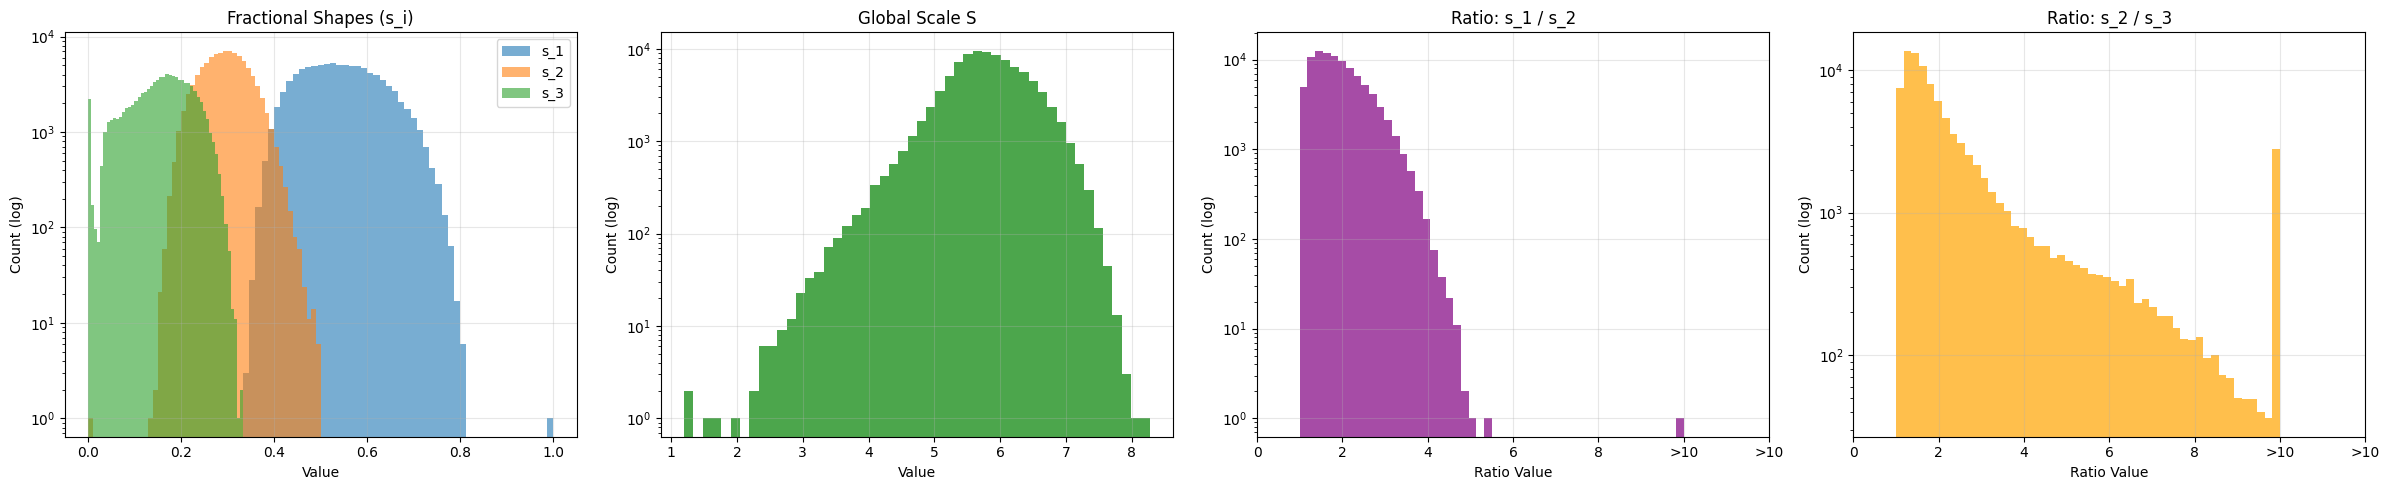

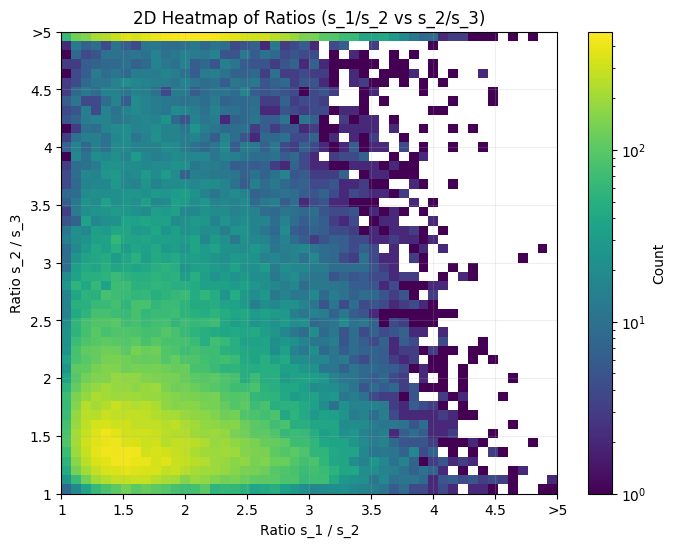

In [27]:
from matplotlib.colors import LogNorm
import matplotlib.ticker as ticker

if dataset_loaded:
    target_attribute = 'eigenvalues_and_scale'
    
    c_list = []
    n_atoms_list = []
    for mol in geom_train:
        c = getattr(mol, 'eigenvalues_and_scale', None)
        if c is None:
            res = compute_eigenvalues_and_scale_axes(mol.pos)
            c = res['c']
        c_list.append(c.numpy() if isinstance(c, torch.Tensor) else c)
        n_atoms_list.append(mol.pos.size(0))
        
    c_arr = np.array(c_list)
    n_atoms_arr = np.array(n_atoms_list)
    
    print(f'First 10 example values of {target_attribute} ([s_1, s_2, s_3, S]):')
    for idx, c_val in enumerate(c_arr[:10]):
        print(f'  Molecule {idx+1}: {c_val.tolist()}')

    eps = 1e-8
    ratio_1_2 = c_arr[:, 0] / (c_arr[:, 1] + eps)
    ratio_2_3 = c_arr[:, 1] / (c_arr[:, 2] + eps)

    n_bins = 50
    clip_1d = 10.0
    clip_2d = 5.0

    fig, axs = plt.subplots(1, 4, figsize=(24, 5), dpi=100)
    
    axs[0].hist(c_arr[:, 0], bins=n_bins, alpha=0.6, label='s_1')
    axs[0].hist(c_arr[:, 1], bins=n_bins, alpha=0.6, label='s_2')
    axs[0].hist(c_arr[:, 2], bins=n_bins, alpha=0.6, label='s_3')
    axs[0].set_title('Fractional Shapes (s_i)')
    axs[0].set_xlabel('Value')
    axs[0].set_ylabel('Count (log)')
    axs[0].set_yscale('log')
    axs[0].legend()
    axs[0].grid(True, alpha=0.3)

    axs[1].hist(c_arr[:, 3], bins=n_bins, alpha=0.7, color='green')
    axs[1].set_title('Global Scale S')
    axs[1].set_xlabel('Value')
    axs[1].set_ylabel('Count (log)')
    axs[1].set_yscale('log')
    axs[1].grid(True, alpha=0.3)

    axs[2].hist(np.clip(ratio_1_2, 1, clip_1d), bins=n_bins, alpha=0.7, color='purple')
    axs[2].set_title('Ratio: s_1 / s_2')
    axs[2].set_xlabel('Ratio Value')
    axs[2].set_ylabel('Count (log)')
    axs[2].set_yscale('log')
    axs[2].grid(True, alpha=0.3)

    axs[3].hist(np.clip(ratio_2_3, 1, clip_1d), bins=n_bins, alpha=0.7, color='orange')
    axs[3].set_title('Ratio: s_2 / s_3')
    axs[3].set_xlabel('Ratio Value')
    axs[3].set_ylabel('Count (log)')
    axs[3].set_yscale('log')
    axs[3].grid(True, alpha=0.3)
    
    # Helper function to format the last tick
    def format_last_tick(ax, clip_val):
        ticks = ax.get_xticks()
        labels = [f"{tick:g}" for tick in ticks]
        for i, tick in enumerate(ticks):
            if tick >= clip_val:
                labels[i] = f">{clip_val:g}"
        ax.set_xticks(ticks)
        ax.set_xticklabels(labels)

    fig.canvas.draw()
    format_last_tick(axs[2], clip_1d)
    format_last_tick(axs[3], clip_1d)

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 6), dpi=100)
    x_vals = np.clip(ratio_1_2, 1, clip_2d)
    y_vals = np.clip(ratio_2_3, 1, clip_2d)
    
    h2d = plt.hist2d(x_vals, y_vals, bins=50, cmap='viridis', norm=LogNorm())
    cbar = plt.colorbar(h2d[3], label='Count')
    plt.title('2D Heatmap of Ratios (s_1/s_2 vs s_2/s_3)')
    plt.xlabel('Ratio s_1 / s_2')
    plt.ylabel('Ratio s_2 / s_3')
    plt.grid(True, alpha=0.2)
    
    ax_2d = plt.gca()
    fig_2d = plt.gcf()
    fig_2d.canvas.draw()
    
    # Format x ticks
    xticks = ax_2d.get_xticks()
    xlabels = [f"{t:g}" if t < clip_2d else f">{clip_2d:g}" for t in xticks]
    ax_2d.set_xticks(xticks)
    ax_2d.set_xticklabels(xlabels)
    
    # Format y ticks
    yticks = ax_2d.get_yticks()
    ylabels = [f"{t:g}" if t < clip_2d else f">{clip_2d:g}" for t in yticks]
    ax_2d.set_yticks(yticks)
    ax_2d.set_yticklabels(ylabels)

    plt.show()
else:
    print("Dataset distribution plot skipped because no preprocessed dataset was loaded.")


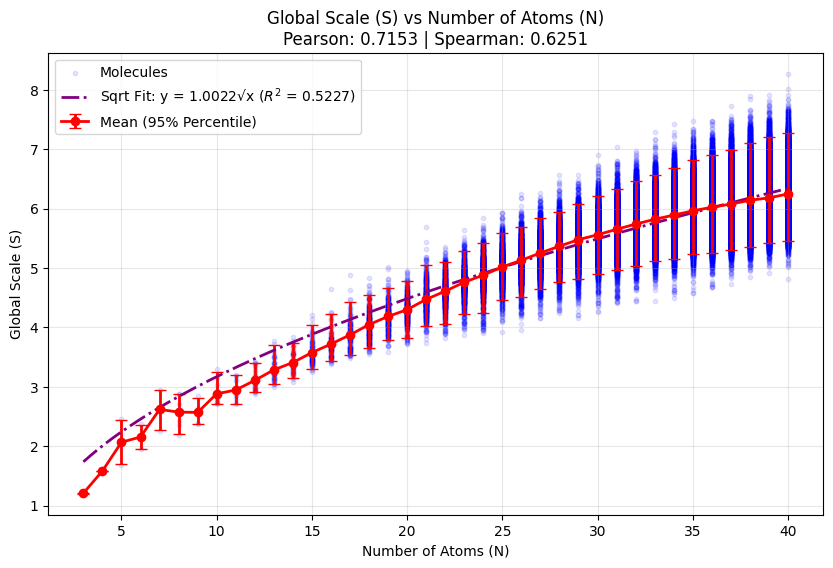

In [28]:
from scipy.stats import pearsonr, spearmanr
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

def sqrt_func(x, a):
    return a * np.sqrt(x)

if dataset_loaded:
    S_vals = c_arr[:, 3]
    
    # Calculate correlations
    pearson_corr, _ = pearsonr(n_atoms_arr, S_vals)
    spearman_corr, _ = spearmanr(n_atoms_arr, S_vals)
    
    unique_n = np.unique(n_atoms_arr)
    means = np.array([np.mean(S_vals[n_atoms_arr == n]) for n in unique_n])
    
    p_lower = np.array([np.percentile(S_vals[n_atoms_arr == n], 2.5) for n in unique_n])
    p_upper = np.array([np.percentile(S_vals[n_atoms_arr == n], 97.5) for n in unique_n])
    
    yerr = [means - p_lower, p_upper - means]
    
    # Square root regression (y = a * sqrt(x))
    popt_sqrt, _ = curve_fit(sqrt_func, n_atoms_arr, S_vals)
    
    # Calculate R-squared for the fit
    y_pred = sqrt_func(n_atoms_arr, *popt_sqrt)
    ss_res = np.sum((S_vals - y_pred) ** 2)
    ss_tot = np.sum((S_vals - np.mean(S_vals)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)
    
    plt.figure(figsize=(10, 6), dpi=100)
    
    # Scatter plot
    plt.scatter(n_atoms_arr, S_vals, alpha=0.1, s=10, color='blue', label='Molecules')
    
    # Mean and 95% Percentile error bars
    plt.errorbar(unique_n, means, yerr=yerr, fmt='o-', color='red', ecolor='red',
                 capsize=4, linewidth=2, markersize=6, label='Mean (95% Percentile)')
                 
    # Linspace array so the non-linear curve renders smoothly
    x_curve = np.linspace(np.min(n_atoms_arr), np.max(n_atoms_arr), 200)
                 
    # Plot sqrt fit with R^2 in the legend
    plt.plot(x_curve, sqrt_func(x_curve, *popt_sqrt), color='purple', linewidth=2, linestyle='-.', 
             label=f'Sqrt Fit: y = {popt_sqrt[0]:.4f}√x ($R^2$ = {r_squared:.4f})')
    
    plt.title(f'Global Scale (S) vs Number of Atoms (N)\nPearson: {pearson_corr:.4f} | Spearman: {spearman_corr:.4f}')
    plt.xlabel('Number of Atoms (N)')
    plt.ylabel('Global Scale (S)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()